# 🩺 Diabetic Retinopathy Grading — Production Pipeline v20
## 30-Step | FULL Resume & Recovery | Windows HP Victus GPU+CPU
### ⚡ Every cell saves progress → Crash → Re-run All → Resumes exactly where it stopped
---
**Targets:** QWK ≥ 0.90 | Accuracy ≥ 85% | F1 ≥ 85% | No overfitting


## 🔁 Step 0 — Global Resume & Recovery System
**Creates all directories + utility functions used by EVERY subsequent cell.**


In [1]:
# ═══════════════════════════════════════════════════════════════
# STEP 0 — GLOBAL RESUME SYSTEM (always runs — instant)
# Creates: /flags/ /checkpoints/ /logs/ /cache/ /artifacts/
# Utilities: is_done, mark_done, save_json, load_json, etc.
# ═══════════════════════════════════════════════════════════════
import os, json, pickle, time, platform
from pathlib import Path

# ── Base directories ──────────────────────────────────────────
HOME        = Path.home()
BASE_DIR    = Path(os.environ.get("DR_BASE", str(HOME / "DR_data")))
DATA_DIR    = BASE_DIR / "aptos2019"
FLAG_DIR    = BASE_DIR / "flags"
CKPT_DIR    = BASE_DIR / "checkpoints"
LOG_DIR     = BASE_DIR / "logs"
CACHE_DIR   = BASE_DIR / "cache"
ARTIFACT_DIR= BASE_DIR / "artifacts"
PLOT_DIR    = BASE_DIR / "plots"
EXPORT_DIR  = BASE_DIR / "export"
DEPLOY_DIR  = BASE_DIR / "deploy"
IMG_DIR     = DATA_DIR / "train_images"
CSV_PATH    = DATA_DIR / "train.csv"

for d in [DATA_DIR, FLAG_DIR, CKPT_DIR, LOG_DIR, CACHE_DIR,
          ARTIFACT_DIR, PLOT_DIR, EXPORT_DIR, DEPLOY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Resume Utilities ──────────────────────────────────────────
def is_done(step_name):
    """Check if step already completed."""
    return (FLAG_DIR / f"{step_name}.done").exists()

def mark_done(step_name):
    """Mark step as completed."""
    (FLAG_DIR / f"{step_name}.done").touch()

def clear_done(step_name):
    """Clear a step flag to force re-run."""
    f = FLAG_DIR / f"{step_name}.done"
    if f.exists(): f.unlink()

def save_json(data, path):
    Path(path).write_text(json.dumps(data, indent=2, default=str))

def load_json(path):
    return json.loads(Path(path).read_text())

def save_pickle(obj, path):
    with open(path, "wb") as f: pickle.dump(obj, f)

def load_pickle(path):
    with open(path, "rb") as f: return pickle.load(f)

# ── State (JSON key-value for training metrics) ──────────────
_STATE_FILE = ARTIFACT_DIR / "training_state.json"
def st_load():
    if _STATE_FILE.exists():
        try: return json.loads(_STATE_FILE.read_text())
        except: return {}
    return {}
def st_save(key, val):
    s = st_load(); s[key] = val
    _STATE_FILE.write_text(json.dumps(s, indent=2, default=str))
def st_get(key, default=None):
    return st_load().get(key, default)

# ── Progress bar helper ──────────────────────────────────────
def show_progress(current, total, prefix="Progress", width=50, extra=""):
    pct = current / max(total, 1) * 100
    filled = int(width * current // max(total, 1))
    bar = "█" * filled + "░" * (width - filled)
    print(f"\r  {prefix} [{bar}] {pct:5.1f}% ({current:,}/{total:,}) {extra}", end="", flush=True)
    if current >= total: print()

# ── Step header/footer ────────────────────────────────────────
def step_start(num, name):
    print("=" * 68)
    print(f"  [STEP {num:02d}] {name}")
    print("=" * 68)
    return time.time()

def step_skip(num, name, detail=""):
    print("=" * 68)
    print(f"  [STEP {num:02d}] {name}")
    print(f"  Status : ✅ ALREADY COMPLETED → Skipping")
    if detail: print(f"  Detail : {detail}")
    print("=" * 68)

def step_end(num, t0, outputs=None):
    elapsed = time.time() - t0
    print(f"\n  Status : ✅ Completed")
    print(f"  Time   : {elapsed:.1f}s")
    if outputs:
        for k, v in outputs.items():
            print(f"  {k:8s}: {v}")
    print("=" * 68)

# ── Constants ─────────────────────────────────────────────────
NUM_CLASSES  = 5
N_FOLDS      = 5
SEED         = 42
GRADE_MAP    = {0:"No DR", 1:"Mild", 2:"Moderate", 3:"Severe", 4:"Proliferative"}
GRADE_COLORS = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print("=" * 68)
print("  [STEP 00] GLOBAL RESUME SYSTEM")
print("=" * 68)
print(f"  BASE_DIR  : {BASE_DIR}")
print(f"  FLAGS     : {FLAG_DIR}")
print(f"  CKPTS     : {CKPT_DIR}")
print(f"  LOGS      : {LOG_DIR}")
print(f"  CACHE     : {CACHE_DIR}")

# Show existing flags
existing = sorted(FLAG_DIR.glob("*.done"))
if existing:
    print(f"\n  📋 Completed steps ({len(existing)}):")
    for f in existing:
        print(f"     ✅ {f.stem}")
else:
    print(f"\n  📋 No completed steps — fresh start")

print("=" * 68)

  [STEP 00] GLOBAL RESUME SYSTEM
  BASE_DIR  : /Users/gokulnathan/DR_data
  FLAGS     : /Users/gokulnathan/DR_data/flags
  CKPTS     : /Users/gokulnathan/DR_data/checkpoints
  LOGS      : /Users/gokulnathan/DR_data/logs
  CACHE     : /Users/gokulnathan/DR_data/cache

  📋 Completed steps (11):
     ✅ cleaning
     ✅ data_load
     ✅ dataset
     ✅ download
     ✅ eda
     ✅ extract
     ✅ install
     ✅ kaggle_auth
     ✅ label_analysis
     ✅ split
     ✅ system


## ⚙️ Step 1 — System Setup (GPU/CPU/Memory + Reproducibility)


In [2]:
# ═══════════════════════════════════════════════════════════════
# STEP 1 — System Setup + Reproducibility (saves system_info.json)
# ═══════════════════════════════════════════════════════════════
import sys, platform, shutil, subprocess

if is_done("system"):
    info = load_json(LOG_DIR / "system_info.json")
    step_skip(1, "SYSTEM SETUP", f"Device: {info.get('device','?')}")
else:
    t0 = step_start(1, "SYSTEM SETUP")

    info = {
        "os": f"{platform.system()} {platform.release()}",
        "python": sys.version.split()[0],
        "arch": platform.machine(),
    }

    # RAM
    try:
        import psutil
        ram = psutil.virtual_memory()
        info["ram_total_gb"] = round(ram.total / 1e9, 1)
        info["ram_avail_gb"] = round(ram.available / 1e9, 1)
        print(f"  RAM     : {info['ram_total_gb']} GB (avail: {info['ram_avail_gb']} GB)")
    except ImportError:
        print("  RAM     : psutil not available")

    # Disk
    _, _, free = shutil.disk_usage(str(HOME))
    info["disk_free_gb"] = round(free / 1e9, 1)
    print(f"  Disk    : {info['disk_free_gb']} GB free")

    # GPU
    try:
        r = subprocess.run(["nvidia-smi","--query-gpu=name,memory.total",
            "--format=csv,noheader"], capture_output=True, text=True, timeout=10)
        if r.returncode == 0:
            info["gpu_nvidia"] = r.stdout.strip()
            print(f"  GPU     : {info['gpu_nvidia']}")
    except FileNotFoundError:
        info["gpu_nvidia"] = "not found"

    # PyTorch + CUDA
    import torch
    info["pytorch"] = torch.__version__
    info["cuda_available"] = torch.cuda.is_available()
    if torch.cuda.is_available():
        info["cuda_version"] = torch.version.cuda
        info["gpu_torch"] = torch.cuda.get_device_name(0)
        info["vram_gb"] = round(torch.cuda.get_device_properties(0).total_mem / 1e9, 1)
        info["device"] = "cuda"
        print(f"  CUDA    : {info['cuda_version']} → {info['gpu_torch']} ({info['vram_gb']} GB)")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        info["device"] = "mps"
        print(f"  MPS     : Available")
    else:
        info["device"] = "cpu"
        print(f"  Device  : CPU only")

    # Reproducibility
    import random, numpy as np
    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
    os.environ["PYTHONHASHSEED"] = str(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"  Seed    : {SEED} (all RNGs seeded)")

    save_json(info, LOG_DIR / "system_info.json")
    mark_done("system")
    step_end(1, t0, {"Output": str(LOG_DIR / "system_info.json")})

  [STEP 01] SYSTEM SETUP
  Status : ✅ ALREADY COMPLETED → Skipping
  Detail : Device: mps


## 📦 Step 2 — Install Requirements (skips already-installed)


In [3]:
# ═══════════════════════════════════════════════════════════════
# STEP 2 — Install Requirements (RESUMABLE: only installs missing)
# ═══════════════════════════════════════════════════════════════
import importlib

if is_done("install"):
    step_skip(2, "INSTALL REQUIREMENTS")
else:
    t0 = step_start(2, "INSTALL REQUIREMENTS")

    _pkgs = {
        "torch":"torch>=2.1","torchvision":"torchvision","torchaudio":"torchaudio",
        "timm":"timm>=1.0.0","albumentations":"albumentations>=1.4.0",
        "cv2":"opencv-python-headless","sklearn":"scikit-learn","scipy":"scipy",
        "pandas":"pandas","numpy":"numpy","tqdm":"tqdm","matplotlib":"matplotlib",
        "pytorch_grad_cam":"grad-cam","streamlit":"streamlit>=1.35.0",
        "huggingface_hub":"huggingface_hub>=0.23.0","kaggle":"kaggle",
        "pyarrow":"pyarrow","PIL":"pillow<11.0","psutil":"psutil",
        "ipywidgets":"ipywidgets","optuna":"optuna",
    }

    missing = []
    for mod, pkg in _pkgs.items():
        try: importlib.import_module(mod)
        except ImportError: missing.append(pkg)

    print(f"  Installed : {len(_pkgs)-len(missing)}/{len(_pkgs)}")
    print(f"  Missing   : {len(missing)}")

    if missing:
        import subprocess
        for i, pkg in enumerate(missing):
            show_progress(i+1, len(missing), "Installing", extra=pkg)
            subprocess.run([sys.executable,"-m","pip","install","-q","--upgrade",pkg],
                           capture_output=True, text=True)
        print(f"  ✅ Installed {len(missing)} packages")
    else:
        print(f"  ✅ Nothing to install")

    mark_done("install")
    step_end(2, t0)

  [STEP 02] INSTALL REQUIREMENTS
  Status : ✅ ALREADY COMPLETED → Skipping


## 🔑 Step 3 — Kaggle Authentication (Upload kaggle.json)


In [4]:
# ═══════════════════════════════════════════════════════════════
# STEP 3 — Kaggle Authentication (RESUMABLE)
# ═══════════════════════════════════════════════════════════════
if is_done("kaggle_auth"):
    kj = Path.home() / ".kaggle" / "kaggle.json"
    usr = "?"
    if kj.exists():
        try: usr = json.loads(kj.read_text()).get("username","?")
        except: pass
    step_skip(3, "KAGGLE AUTH", f"User: {usr}")
else:
    t0 = step_start(3, "KAGGLE AUTHENTICATION")

    KAGGLE_DIR  = Path.home() / ".kaggle"
    KAGGLE_JSON = KAGGLE_DIR / "kaggle.json"

    if KAGGLE_JSON.exists():
        d = json.loads(KAGGLE_JSON.read_text())
        print(f"  ✅ Already configured — user: {d.get('username','?')}")
    else:
        ku = os.environ.get("KAGGLE_USERNAME","")
        kk = os.environ.get("KAGGLE_KEY","")
        if ku and kk:
            KAGGLE_DIR.mkdir(parents=True, exist_ok=True)
            KAGGLE_JSON.write_text(json.dumps({"username":ku,"key":kk}))
            if platform.system() != "Windows": KAGGLE_JSON.chmod(0o600)
            print(f"  ✅ Written from env vars — user: {ku}")
        else:
            try:
                import ipywidgets as widgets
                from IPython.display import display, HTML
                display(HTML("<h4>📁 Upload your kaggle.json file:</h4>"))
                _up = widgets.FileUpload(accept=".json", multiple=False, description="kaggle.json")
                _lbl = widgets.Label("⏳ Waiting for upload...")
                def _on(change):
                    if _up.value:
                        uv = list(_up.value.values())[0] if isinstance(_up.value, dict) else _up.value[0]
                        ct = uv["content"] if isinstance(uv, dict) else uv.content
                        KAGGLE_DIR.mkdir(parents=True, exist_ok=True)
                        KAGGLE_JSON.write_bytes(ct if isinstance(ct, bytes) else ct.tobytes())
                        if platform.system() != "Windows": KAGGLE_JSON.chmod(0o600)
                        d2 = json.loads(KAGGLE_JSON.read_text())
                        _lbl.value = f"✅ Installed! User: {d2.get('username','?')}"
                        mark_done("kaggle_auth")
                _up.observe(_on, names="value")
                display(_up, _lbl)
                display(HTML(f"<p><b>Manual:</b> <code>{KAGGLE_JSON}</code></p>"))
            except ImportError:
                print(f"  ⚠️ Place kaggle.json at: {KAGGLE_JSON}")

    if KAGGLE_JSON.exists():
        os.environ["KAGGLE_CONFIG_DIR"] = str(KAGGLE_DIR)
        mark_done("kaggle_auth")
        step_end(3, t0, {"Config": str(KAGGLE_JSON)})
    else:
        print("  ⚠️ Upload kaggle.json above, then re-run this cell.")
        print("=" * 68)

  [STEP 03] KAGGLE AUTH
  Status : ✅ ALREADY COMPLETED → Skipping
  Detail : User: gokulnathanganesan


## 📥 Step 4 — Dataset Download & Extraction (APTOS 2019)


In [5]:
# ═══════════════════════════════════════════════════════════════
# STEP 4 — Download + Extract (RESUMABLE: flag per sub-step)
# ═══════════════════════════════════════════════════════════════
import zipfile

if is_done("extract"):
    n = len(list(IMG_DIR.glob("*.png"))) if IMG_DIR.exists() else 0
    step_skip(4, "DATASET DOWNLOAD & EXTRACTION", f"{n:,} images")
else:
    t0 = step_start(4, "DATASET DOWNLOAD & EXTRACTION")

    ZIP = DATA_DIR / "aptos2019-blindness-detection.zip"

    # ── Download ──────────────────────────────────────────────
    if not is_done("download"):
        if not ZIP.exists():
            print("  📥 Downloading APTOS 2019 (~9.5 GB)...")
            import subprocess
            r = subprocess.run(
                [sys.executable,"-m","kaggle","competitions","download",
                 "-c","aptos2019-blindness-detection","-p",str(DATA_DIR)],
                capture_output=True, text=True
            )
            if r.returncode != 0:
                print(f"  ❌ FAILED: {r.stderr[-500:]}")
                raise RuntimeError("Kaggle download failed. Accept rules at kaggle.com first.")
            print(f"  ✅ Downloaded ({ZIP.stat().st_size/1e9:.2f} GB)")
        else:
            print(f"  ✅ ZIP exists ({ZIP.stat().st_size/1e9:.2f} GB) — skip download")
        mark_done("download")
    else:
        print("  ✅ Download already done")

    # ── Extract ───────────────────────────────────────────────
    if not ZIP.exists():
        # try alternate name
        alt = list(DATA_DIR.glob("*.zip"))
        if alt: ZIP = alt[0]

    print(f"  📦 Extracting {ZIP.name}...")
    with zipfile.ZipFile(ZIP, "r") as zf:
        members = zf.namelist()
        total = len(members)
        for i, m in enumerate(members):
            zf.extract(m, DATA_DIR)
            if (i+1) % max(1, total//40) == 0 or i == total-1:
                show_progress(i+1, total, "Extract")

    mark_done("extract")
    n = len(list(IMG_DIR.glob("*.png"))) if IMG_DIR.exists() else 0
    step_end(4, t0, {"Images": f"{n:,}", "Path": str(IMG_DIR)})

  [STEP 04] DATASET DOWNLOAD & EXTRACTION
  Status : ✅ ALREADY COMPLETED → Skipping
  Detail : 3,662 images


## 🔄 Optional Utility — Reset All Artifacts

> **Run this cell only when you want to force-restart the entire pipeline from scratch.**  
> It clears all `.done` flags, deletes cached artefacts, and reloads `df` from the raw CSV.  
> **Do NOT run during normal resume — Step 0 already handles recovery.**

In [16]:
# ── Nuke ALL stale artifacts completely ──
import shutil

# Clear ALL flags
for f in FLAG_DIR.glob("*.done"):
    f.unlink()
    print(f"✅ Cleared flag : {f.name}")

# Clear stale parquet/artifacts
for path in [
    ARTIFACT_DIR / "df_clean.parquet",
    ARTIFACT_DIR / "kfold_splits.parquet",
    ARTIFACT_DIR / "fold_qwks.json",
    ARTIFACT_DIR / "oof_probs.npy",
    ARTIFACT_DIR / "oof_labels.npy",
]:
    if path.exists():
        path.unlink()
        print(f"✅ Deleted file : {path.name}")

# Clear cache (preprocessed from old 1164 images)
if CACHE_DIR.exists():
    shutil.rmtree(CACHE_DIR)
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    print(f"✅ Cleared cache : {CACHE_DIR}")

# Hard reload df from raw CSV right now
df = pd.read_csv(CSV_PATH)
df["image_path"]  = df["id_code"].apply(lambda x: str(IMG_DIR / f"{x}.png"))
df["grade_label"] = df["diagnosis"].map(GRADE_MAP)
df["binary"]      = (df["diagnosis"] >= 1).astype(int)
df = df[df["image_path"].apply(lambda p: Path(p).exists())].reset_index(drop=True)

print(f"\n✅ df reloaded from raw CSV: {len(df):,} images")
print(f"   Now re-run Step 5 → should show 3,662 images")

✅ Cleared flag : data_load.done
✅ Cleared flag : download.done
✅ Cleared flag : eda.done
✅ Cleared flag : cleaning.done
✅ Cleared flag : label_analysis.done
✅ Cleared flag : kfold.done
✅ Cleared flag : kaggle_auth.done
✅ Cleared flag : preprocess.done
✅ Cleared flag : split.done
✅ Cleared flag : extract.done
✅ Cleared flag : dataset.done
✅ Cleared flag : system.done
✅ Cleared flag : install.done
✅ Deleted file : df_clean.parquet
✅ Deleted file : kfold_splits.parquet
✅ Cleared cache : /Users/gokulnathan/DR_data/cache

✅ df reloaded from raw CSV: 3,662 images
   Now re-run Step 5 → should show 3,662 images


## 📊 Step 5 — Load Dataset + ALL Imports (Master Reload)
**This cell re-establishes ALL imports after kernel restart. Always runs.**


In [17]:
# ═══════════════════════════════════════════════════════════════
# STEP 5 — MASTER RELOAD: imports + load CSV + verify images
# Always runs (fast) — rebuilds full state after kernel restart
# ═══════════════════════════════════════════════════════════════
import os, sys, io, json, gc, time, random, shutil, warnings, pickle, platform
from pathlib import Path
from copy import deepcopy
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tqdm.auto import tqdm
from scipy.optimize import minimize

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
    roc_auc_score, cohen_kappa_score, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, log_loss)

warnings.filterwarnings("ignore")

t0 = step_start(5, "LOAD DATASET + MASTER RELOAD")

# ── Reproducibility ───────────────────────────────────────────
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
seed_everything()

# ── Device ────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = "cuda"
elif hasattr(torch.backends,"mps") and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
USE_AMP = (DEVICE == "cuda")
print(f"  Device  : {DEVICE.upper()} | AMP: {'ON' if USE_AMP else 'OFF'}")
print(f"  PyTorch : {torch.__version__} | timm: {timm.__version__}")

# ── Safe torch.load ───────────────────────────────────────────
def safe_load(path, map_location="cpu"):
    try: return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError: return torch.load(path, map_location=map_location)

# ── Load CSV ──────────────────────────────────────────────────
if not CSV_PATH.exists():
    raise FileNotFoundError(f"train.csv not found at {CSV_PATH}. Run Step 4.")

df = pd.read_csv(CSV_PATH)
df["image_path"]  = df["id_code"].apply(lambda x: str(IMG_DIR / f"{x}.png"))
df["grade_label"] = df["diagnosis"].map(GRADE_MAP)
df["binary"]      = (df["diagnosis"] >= 1).astype(int)

# Verify images exist
missing = df[~df["image_path"].apply(lambda p: Path(p).exists())]
if len(missing):
    print(f"  ⚠️ {len(missing)} missing → dropping")
    df = df[df["image_path"].apply(lambda p: Path(p).exists())].reset_index(drop=True)

# ── Restore saved state ──────────────────────────────────────
# If cleaning was done, load clean df
_clean_path = ARTIFACT_DIR / "df_clean.parquet"
if is_done("cleaning") and _clean_path.exists():
    df = pd.read_parquet(_clean_path)
    df["image_path"]  = df["id_code"].apply(lambda x: str(IMG_DIR / f"{x}.png"))
    df["grade_label"] = df["diagnosis"].map(GRADE_MAP)
    df["binary"]      = (df["diagnosis"] >= 1).astype(int)
    print(f"  📂 Loaded CLEAN dataset: {len(df):,} rows")

# If kfold was done, load splits
_splits_path = ARTIFACT_DIR / "kfold_splits.parquet"
if is_done("kfold") and _splits_path.exists():
    df = pd.read_parquet(_splits_path)
    df["image_path"]  = df["id_code"].apply(lambda x: str(IMG_DIR / f"{x}.png"))
    df["grade_label"] = df["diagnosis"].map(GRADE_MAP)
    df["binary"]      = (df["diagnosis"] >= 1).astype(int)
    print(f"  📂 Loaded K-FOLD splits: {len(df):,} rows, {N_FOLDS} folds")

# ── USE_CACHE flag ────────────────────────────────────────────
USE_CACHE = is_done("preprocess") and CACHE_DIR.exists()
CACHE_SIZE = 384

print(f"\n  Dataset : {len(df):,} images | {NUM_CLASSES} classes")
for g in range(5):
    n = (df["diagnosis"] == g).sum()
    bar = "█" * (n // 60)
    print(f"    G{g} ({GRADE_MAP[g]:14s}): {n:5d} {bar}")

mark_done("data_load")
step_end(5, t0, {"Rows": f"{len(df):,}", "Cache": str(USE_CACHE)})

  [STEP 05] LOAD DATASET + MASTER RELOAD
  Device  : MPS | AMP: OFF
  PyTorch : 2.8.0 | timm: 1.0.26

  Dataset : 3,662 images | 5 classes
    G0 (No DR         ):  1805 ██████████████████████████████
    G1 (Mild          ):   370 ██████
    G2 (Moderate      ):   999 ████████████████
    G3 (Severe        ):   193 ███
    G4 (Proliferative ):   295 ████

  Status : ✅ Completed
  Time   : 0.1s
  Rows    : 3,662
  Cache   : False


## 🧹 Step 6 — Data Cleaning (corrupted, black, blurry, blue images)


In [19]:
# ═══════════════════════════════════════════════════════════════
# STEP 6 — Data Cleaning (RESUMABLE) — conservative / fundus-safe
# Only removes: unreadable, completely black, severely corrupted
# ═══════════════════════════════════════════════════════════════
if is_done("cleaning"):
    df = pd.read_parquet(ARTIFACT_DIR / "df_clean.parquet")
    df["image_path"]  = df["id_code"].apply(lambda x: str(IMG_DIR / f"{x}.png"))
    df["grade_label"] = df["diagnosis"].map(GRADE_MAP)
    df["binary"]      = (df["diagnosis"] >= 1).astype(int)
    step_skip(6, "DATA CLEANING", f"{len(df):,} clean images")
else:
    t0 = step_start(6, "DATA CLEANING")

    def _quality(path):
        # ── 1. Unreadable / corrupt file ──────────────────────────
        bgr = cv2.imread(str(path))
        if bgr is None:
            return False, "unreadable"

        # ── 2. Absurdly small (broken download) ───────────────────
        h, w = bgr.shape[:2]
        if h < 50 or w < 50:
            return False, "too_small"

        # ── 3. Completely black (empty / failed capture) ──────────
        gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
        if float(gray.mean()) < 3.0:
            return False, "black"

        # ── 4. Virtually no bright pixels (almost entirely black) ─
        bright_ratio = float((gray > 10).sum()) / (h * w)
        if bright_ratio < 0.02:          # <2 % bright pixels
            return False, "black"

        return True, "ok"

    results = []
    total = len(df)
    for i, (_, row) in enumerate(df.iterrows()):
        valid, reason = _quality(row["image_path"])
        results.append({"id_code": row["id_code"], "valid": valid, "reason": reason})
        if (i+1) % max(1, total//40) == 0 or i == total-1:
            show_progress(i+1, total, "Cleaning")

    res_df = pd.DataFrame(results)
    invalid = res_df[~res_df["valid"]]
    print(f"\n  Removed  : {len(invalid):,}")
    for reason, cnt in invalid["reason"].value_counts().items():
        print(f"    {reason:15s}: {cnt}")

    valid_ids = set(res_df[res_df["valid"]]["id_code"])
    df = df[df["id_code"].isin(valid_ids)].reset_index(drop=True)
    df["grade_label"] = df["diagnosis"].map(GRADE_MAP)
    df["binary"] = (df["diagnosis"] >= 1).astype(int)
    df.to_parquet(ARTIFACT_DIR / "df_clean.parquet", index=False)

    save_json({"total": total, "removed": len(invalid),
               "reasons": invalid["reason"].value_counts().to_dict()},
              LOG_DIR / "cleaning_report.json")

    mark_done("cleaning")
    step_end(6, t0, {"Clean": f"{len(df):,}", "Removed": f"{len(invalid):,}"})

  [STEP 06] DATA CLEANING
  Status : ✅ ALREADY COMPLETED → Skipping
  Detail : 3,662 clean images


## 📈 Step 7 — EDA (class distribution, samples, brightness)


  [STEP 07] EXPLORATORY DATA ANALYSIS


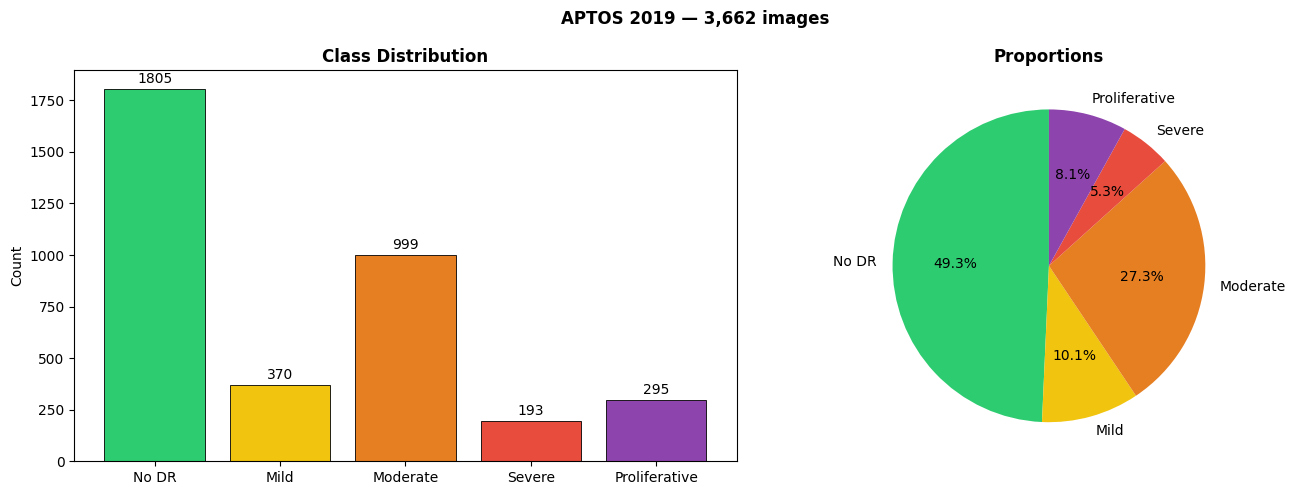

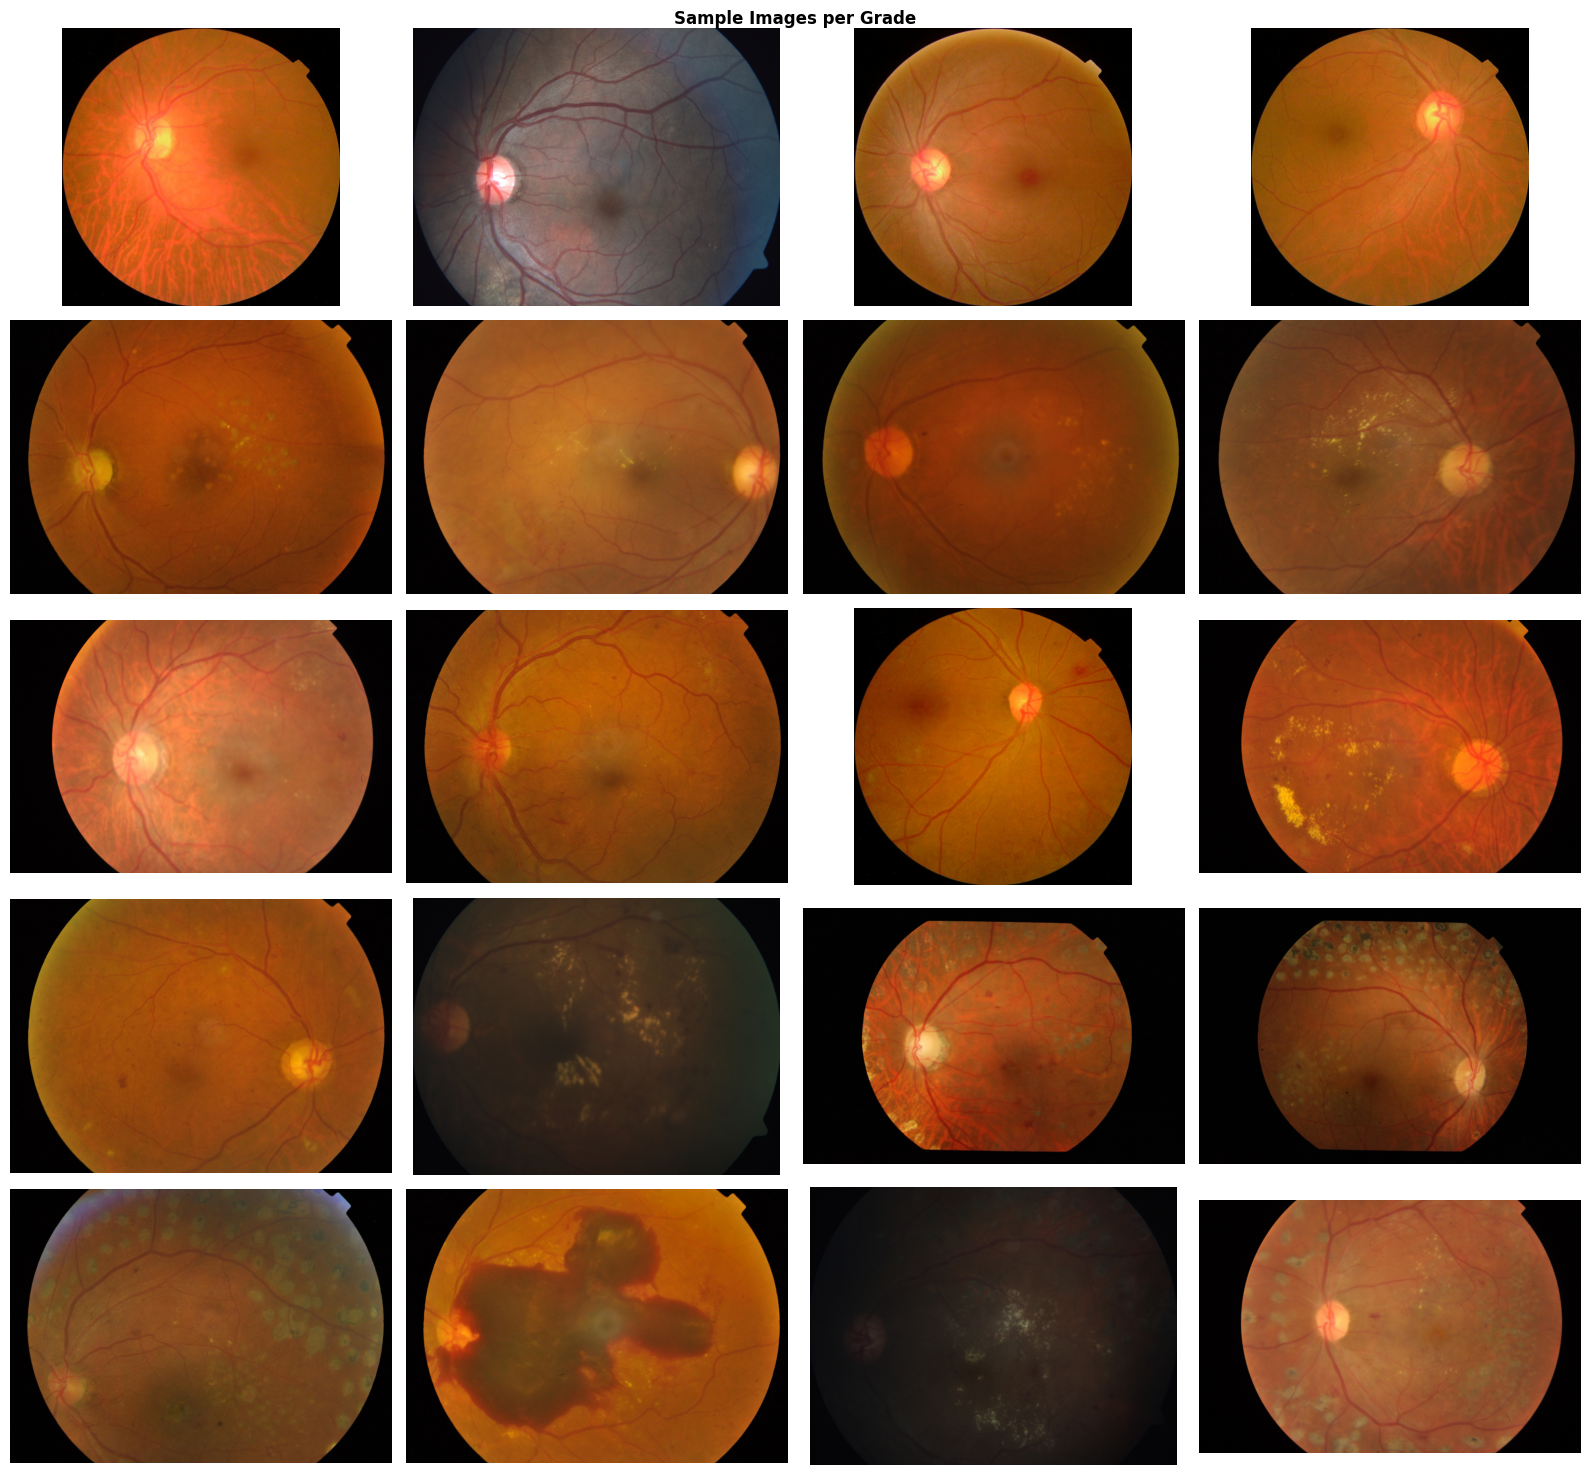


  Status : ✅ Completed
  Time   : 13.2s
  Plots   : /Users/gokulnathan/DR_data/logs/eda


In [20]:
# ═══════════════════════════════════════════════════════════════
# STEP 7 — EDA (RESUMABLE)
# ═══════════════════════════════════════════════════════════════
if is_done("eda"):
    step_skip(7, "EDA")
else:
    t0 = step_start(7, "EXPLORATORY DATA ANALYSIS")
    %matplotlib inline

    (LOG_DIR / "eda").mkdir(exist_ok=True)

    # Distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    counts = df["diagnosis"].value_counts().sort_index()
    axes[0].bar([GRADE_MAP[i] for i in range(5)], counts.values,
                color=GRADE_COLORS, edgecolor="k", linewidth=0.6)
    axes[0].set_title("Class Distribution", fontweight="bold")
    axes[0].set_ylabel("Count")
    for i, v in enumerate(counts.values):
        axes[0].text(i, v + 30, str(v), ha="center", fontsize=10)
    axes[1].pie(counts.values, labels=[GRADE_MAP[i] for i in range(5)],
                colors=GRADE_COLORS, autopct="%1.1f%%", startangle=90)
    axes[1].set_title("Proportions", fontweight="bold")
    plt.suptitle(f"APTOS 2019 — {len(df):,} images", fontweight="bold")
    plt.tight_layout()
    plt.savefig(LOG_DIR / "eda" / "distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Sample images
    fig2, axes2 = plt.subplots(5, 4, figsize=(16, 15))
    for g in range(5):
        sub = df[df["diagnosis"]==g].sample(min(4,(df["diagnosis"]==g).sum()), random_state=SEED)
        for j, (_, row) in enumerate(sub.iterrows()):
            img = cv2.imread(row["image_path"])
            if img is not None: img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes2[g][j].imshow(img if img is not None else np.zeros((100,100,3),np.uint8))
            axes2[g][j].axis("off")
            if j == 0: axes2[g][j].set_ylabel(f"G{g}", fontsize=12, fontweight="bold")
    plt.suptitle("Sample Images per Grade", fontweight="bold")
    plt.tight_layout()
    plt.savefig(LOG_DIR / "eda" / "samples.png", dpi=120, bbox_inches="tight")
    plt.show()

    mark_done("eda")
    step_end(7, t0, {"Plots": str(LOG_DIR / "eda")})

## ⚖️ Step 8 — Label Analysis + Class Weights


In [21]:
# ═══════════════════════════════════════════════════════════════
# STEP 8 — Label Analysis (RESUMABLE)
# ═══════════════════════════════════════════════════════════════
if is_done("label_analysis"):
    weights_data = load_json(LOG_DIR / "weights.json")
    step_skip(8, "LABEL ANALYSIS", f"Imbalance: {weights_data.get('imbalance_ratio','?')}x")
else:
    t0 = step_start(8, "LABEL ANALYSIS + CLASS WEIGHTS")

    vc = df["diagnosis"].value_counts().sort_index()
    counts = np.bincount(df["diagnosis"].values, minlength=NUM_CLASSES).astype(float)
    cw = len(df) / (NUM_CLASSES * np.maximum(counts, 1))
    cw_norm = cw / cw.sum() * NUM_CLASSES

    weights_data = {
        "class_counts": {str(k): int(v) for k, v in vc.items()},
        "class_weights": {str(i): round(float(cw_norm[i]), 4) for i in range(5)},
        "imbalance_ratio": round(float(vc.max() / vc.min()), 1),
    }

    for g, c in vc.items():
        pct = c / len(df) * 100
        print(f"  G{g} ({GRADE_MAP[g]:14s}): {c:5d} ({pct:5.1f}%) weight={cw_norm[g]:.3f}")

    print(f"\n  Imbalance ratio: {weights_data['imbalance_ratio']}x")
    print("  → WeightedRandomSampler + class-weighted loss MANDATORY")

    save_json(weights_data, LOG_DIR / "weights.json")
    mark_done("label_analysis")
    step_end(8, t0)

  [STEP 08] LABEL ANALYSIS + CLASS WEIGHTS
  G0 (No DR         ):  1805 ( 49.3%) weight=0.216
  G1 (Mild          ):   370 ( 10.1%) weight=1.053
  G2 (Moderate      ):   999 ( 27.3%) weight=0.390
  G3 (Severe        ):   193 (  5.3%) weight=2.019
  G4 (Proliferative ):   295 (  8.1%) weight=1.321

  Imbalance ratio: 9.4x
  → WeightedRandomSampler + class-weighted loss MANDATORY

  Status : ✅ Completed
  Time   : 0.0s


## 🧠 Step 9 — Preprocessing Pipeline (retina crop, Ben Graham, CLAHE)


In [22]:
# ═══════════════════════════════════════════════════════════════
# STEP 9 — Preprocessing Functions (always defines — instant)
# ═══════════════════════════════════════════════════════════════
t0 = step_start(9, "PREPROCESSING PIPELINE")

IMG_SIZE = int(os.environ.get("IMG_SIZE", 512))

def _circ_mask(img):
    h, w = img.shape[:2]; mask = np.zeros((h,w), np.uint8)
    cv2.circle(mask, (w//2, h//2), int(min(h,w)//2*0.97), 255, -1); return mask

def _clahe_lab(rgb):
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    lab[:,:,0] = cv2.createCLAHE(2.0, (8,8)).apply(lab[:,:,0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def preprocess_fundus(path_or_arr, size=None):
    target = size or IMG_SIZE
    if isinstance(path_or_arr, np.ndarray): rgb = path_or_arr.copy()
    else:
        bgr = cv2.imread(str(path_or_arr))
        if bgr is None: return np.zeros((target,target,3), np.uint8)
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    # Crop black borders
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    _, th = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(th)
    if coords is not None:
        x,y,w,h = cv2.boundingRect(coords); rgb = rgb[y:y+h, x:x+w]
    # Resize + pad
    h, w = rgb.shape[:2]; s = target / max(h,w)
    nh, nw = int(round(h*s)), int(round(w*s))
    rgb = cv2.resize(rgb, (nw,nh), interpolation=cv2.INTER_AREA)
    pt=(target-nh)//2; pb=target-nh-pt; pl=(target-nw)//2; pr=target-nw-pl
    rgb = cv2.copyMakeBorder(rgb, pt, pb, pl, pr, cv2.BORDER_REFLECT_101)
    mask = _circ_mask(rgb); rgb[mask==0] = 0
    rgb = _clahe_lab(rgb)
    # Ben Graham
    sig = max((target//10)|1, 1)
    blur = cv2.GaussianBlur(rgb, (0,0), sigmaX=sig)
    rgb = cv2.addWeighted(rgb, 4, blur, -4, 128); rgb[mask==0] = 0
    # Green emphasis
    out = rgb.astype(np.float32); out[:,:,1] = np.clip(out[:,:,1]*1.1, 0, 255)
    return out.astype(np.uint8)

# Benchmark
lat = 0
if len(df) > 0:
    _t = time.time()
    for _ in range(3): preprocess_fundus(df["image_path"].iloc[0])
    lat = (time.time()-_t)/3*1000
    print(f"  Latency : {lat:.1f} ms/image")

print(f"  IMG_SIZE: {IMG_SIZE}")
mark_done("preprocessing_fns")
step_end(9, t0, {"Latency": f"{lat:.1f}ms"})

  [STEP 09] PREPROCESSING PIPELINE
  Latency : 382.1 ms/image
  IMG_SIZE: 512

  Status : ✅ Completed
  Time   : 1.1s
  Latency : 382.1ms


## 💾 Step 10 — Preprocessing Cache (skip already cached)


In [24]:
# ═══════════════════════════════════════════════════════════════
# STEP 10 — Preprocessing Cache (RESUMABLE + PARALLEL)
# ═══════════════════════════════════════════════════════════════
if is_done("preprocess"):
    n = len(list(CACHE_DIR.glob("*.npy")))
    USE_CACHE = True
    step_skip(10, "PREPROCESSING CACHE", f"{n:,} cached at {CACHE_SIZE}px")
else:
    t0 = step_start(10, "PREPROCESSING CACHE")
    CACHE_DIR.mkdir(parents=True, exist_ok=True)

    existing = set(p.stem for p in CACHE_DIR.glob("*.npy"))
    to_process = df[~df["id_code"].isin(existing)].reset_index(drop=True)
    print(f"  Already cached : {len(existing):,}")
    print(f"  To process     : {len(to_process):,}")

    ok = fail = 0
    total = len(to_process)
    lock = __import__("threading").Lock()
    counter = [0]

    def _cache_one(row):
        try:
            img = preprocess_fundus(row["image_path"], size=CACHE_SIZE)
            np.save(str(CACHE_DIR / f'{row["id_code"]}.npy'), img)
            return True
        except Exception:
            return False

    N_WORKERS = min(8, os.cpu_count() or 4)
    rows = [to_process.iloc[i] for i in range(total)]

    from concurrent.futures import ThreadPoolExecutor, as_completed
    with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
        futures = {ex.submit(_cache_one, row): row for row in rows}
        for fut in as_completed(futures):
            result = fut.result()
            with lock:
                if result: ok += 1
                else: fail += 1
                done = ok + fail
                if done % max(1, total // 40) == 0 or done == total:
                    show_progress(done, total, "Caching")

    USE_CACHE = True
    mark_done("preprocess")
    step_end(10, t0, {"Cached": f"{ok + len(existing):,}", "Failed": str(fail)})

  [STEP 10] PREPROCESSING CACHE
  Already cached : 690
  To process     : 2,972
  Caching [██████████████████████████████████████████████████] 100.0% (2,972/2,972) 

  Status : ✅ Completed
  Time   : 183.3s
  Cached  : 3,662
  Failed  : 0


## ✂️ Step 11 — Train / Test Split (hold-out fold 0)


In [25]:
# ═══════════════════════════════════════════════════════════════
# STEP 11 — Train/Test Split (RESUMABLE: documented in K-Fold)
# ═══════════════════════════════════════════════════════════════
if is_done("split"):
    step_skip(11, "TRAIN/TEST SPLIT", "Fold 0 = hold-out test")
else:
    t0 = step_start(11, "TRAIN / TEST SPLIT")
    print("  Strategy: Fold 0 = HELD-OUT TEST SET (never trained on)")
    print("  Folds 1-4 = cross-validation training")
    mark_done("split")
    step_end(11, t0)

  [STEP 11] TRAIN / TEST SPLIT
  Strategy: Fold 0 = HELD-OUT TEST SET (never trained on)
  Folds 1-4 = cross-validation training

  Status : ✅ Completed
  Time   : 0.0s


## 🔁 Step 12 — Stratified K-Fold (5 folds)


In [26]:
# ═══════════════════════════════════════════════════════════════
# STEP 12 — Stratified K-Fold (RESUMABLE)
# ═══════════════════════════════════════════════════════════════
if is_done("kfold"):
    df = pd.read_parquet(ARTIFACT_DIR / "kfold_splits.parquet")
    df["image_path"]  = df["id_code"].apply(lambda x: str(IMG_DIR / f"{x}.png"))
    df["grade_label"] = df["diagnosis"].map(GRADE_MAP)
    df["binary"]      = (df["diagnosis"] >= 1).astype(int)
    step_skip(12, "K-FOLD SPLIT", f"{N_FOLDS} folds, {len(df):,} rows")
else:
    t0 = step_start(12, "STRATIFIED K-FOLD")
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    df["fold"] = -1
    for fi, (_, vi) in enumerate(skf.split(df, df["diagnosis"])):
        df.loc[vi, "fold"] = fi
    df.to_parquet(ARTIFACT_DIR / "kfold_splits.parquet", index=False)
    for fold in range(N_FOLDS):
        n = (df["fold"]==fold).sum()
        gd = df[df["fold"]==fold]["diagnosis"].value_counts().sort_index()
        gs = " ".join([f"G{g}:{c}" for g,c in gd.items()])
        print(f"  Fold {fold}: {n:5d} [{gs}]")
    mark_done("kfold")
    step_end(12, t0)

  [STEP 12] STRATIFIED K-FOLD
  Fold 0:   733 [G0:361 G1:74 G2:200 G3:39 G4:59]
  Fold 1:   733 [G0:361 G1:74 G2:200 G3:39 G4:59]
  Fold 2:   732 [G0:361 G1:74 G2:200 G3:38 G4:59]
  Fold 3:   732 [G0:361 G1:74 G2:200 G3:38 G4:59]
  Fold 4:   732 [G0:361 G1:74 G2:199 G3:39 G4:59]

  Status : ✅ Completed
  Time   : 0.0s


## 🔧 Step 13 — Augmentation + Dataset + Sampler


In [28]:
# ═══════════════════════════════════════════════════════════════
# STEP 13 — Augmentations, Datasets, Sampler (always defines)
# ═══════════════════════════════════════════════════════════════
t0 = step_start(13, "AUGMENTATION + DATASET PIPELINE")

def build_train_tf(sz=IMG_SIZE):
    return A.Compose([
        A.RandomResizedCrop(size=(sz, sz), scale=(0.8,1.0), ratio=(0.9,1.1), p=1.0),
        A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5), A.Rotate(limit=15,p=0.7),
        A.CLAHE(clip_limit=2.0,tile_grid_size=(8,8),p=0.3),
        A.RandomBrightnessContrast(0.2,0.2,p=0.5),
        A.HueSaturationValue(10,20,10,p=0.3), A.RandomGamma((80,120),p=0.3),
        A.GaussNoise(var_limit=(10,50),p=0.2), A.MotionBlur(blur_limit=3,p=0.1),
        A.CoarseDropout(num_holes_range=(1,8),
                        hole_height_range=(sz//16, sz//16),
                        hole_width_range=(sz//16, sz//16), p=0.2),
        A.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD), ToTensorV2(),
    ])

def build_val_tf(sz=IMG_SIZE):
    return A.Compose([A.Resize(sz,sz),A.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD),ToTensorV2()])

def build_tta_tf(sz=IMG_SIZE):
    n=A.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD); r=A.Resize(sz,sz)
    return [build_val_tf(sz),
        A.Compose([A.HorizontalFlip(p=1),r,n,ToTensorV2()]),
        A.Compose([A.Rotate(limit=(10,10),p=1),r,n,ToTensorV2()]),
        A.Compose([A.Rotate(limit=(-10,-10),p=1),r,n,ToTensorV2()]),
        A.Compose([A.VerticalFlip(p=1),r,n,ToTensorV2()]),]

class APTOSDataset(Dataset):
    def __init__(self, df, transform=None, img_size=None, use_cache=True):
        self.df=df.reset_index(drop=True); self.tf=transform
        self.sz=img_size or IMG_SIZE; self.cache=use_cache and USE_CACHE
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row=self.df.iloc[idx]; label=int(row["diagnosis"])
        if self.cache:
            cp=CACHE_DIR/f'{row["id_code"]}.npy'
            if cp.exists():
                img=np.load(str(cp))
                if self.sz!=CACHE_SIZE: img=cv2.resize(img,(self.sz,self.sz),interpolation=cv2.INTER_AREA)
            else: img=preprocess_fundus(row["image_path"],size=self.sz)
        else: img=preprocess_fundus(row["image_path"],size=self.sz)
        if self.tf: img=self.tf(image=img)["image"]
        else: img=torch.from_numpy(img.transpose(2,0,1)).float()/255.0
        return img, label

def build_sampler(df_s):
    labs=df_s["diagnosis"].values; c=np.bincount(labs,minlength=5).astype(float)
    w=1.0/np.maximum(c,1); sw=w[labs]
    return WeightedRandomSampler(torch.DoubleTensor(sw),len(sw),replacement=True)

def make_loader(ds,batch_size=16,shuffle=True,sampler=None,drop_last=False):
    if sampler: shuffle=False
    nw=0 if platform.system()=="Windows" else min(4,os.cpu_count() or 1)
    return DataLoader(ds,batch_size=batch_size,shuffle=shuffle,sampler=sampler,
        num_workers=nw,pin_memory=(DEVICE=="cuda"),persistent_workers=(nw>0),drop_last=drop_last)

BS_MAP = {224:32, 384:16, 512:8}
tta_transforms_lst = build_tta_tf(IMG_SIZE)

mark_done("dataset")
print(f"  Train augmentations : {len(build_train_tf(224).transforms)} ops")
print(f"  TTA views           : {len(tta_transforms_lst)}")
print(f"  Batch sizes         : {BS_MAP}")
step_end(13, t0)

  [STEP 13] AUGMENTATION + DATASET PIPELINE
  Train augmentations : 13 ops
  TTA views           : 5
  Batch sizes         : {224: 32, 384: 16, 512: 8}

  Status : ✅ Completed
  Time   : 0.0s


## 🚚 Step 14 — DataLoader Sanity Check


In [30]:
# ═══════════════════════════════════════════════════════════════
# STEP 14 — DataLoader Sanity Check (RESUMABLE)
# ═══════════════════════════════════════════════════════════════

# ── Override make_loader: num_workers=0 for macOS spawn ───────
def make_loader(ds, batch_size=16, shuffle=True, sampler=None, drop_last=False):
    if sampler: shuffle = False
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, sampler=sampler,
        num_workers=0, pin_memory=(DEVICE=="cuda"), persistent_workers=False, drop_last=drop_last)

if is_done("dataloader"):
    step_skip(14, "DATALOADER CHECK")
else:
    t0 = step_start(14, "DATALOADER SANITY CHECK")

    _bs = BS_MAP.get(224, 16)
    _d  = APTOSDataset(df[df["fold"]!=0].head(64), transform=build_val_tf(224), img_size=224)
    _l  = DataLoader(_d, batch_size=_bs, shuffle=True, num_workers=0)

    imgs, labs = next(iter(_l))
    print(f"  Batch shape : {imgs.shape}")
    print(f"  Labels      : {labs[:8].tolist()}")
    assert imgs.shape[1] == 3, "Channel mismatch"
    assert imgs.shape[2] == 224 and imgs.shape[3] == 224, "Size mismatch"
    assert imgs.dtype == torch.float32, "dtype mismatch"

    del _d, _l, imgs, labs; gc.collect()
    mark_done("dataloader")
    step_end(14, t0)

  [STEP 14] DATALOADER SANITY CHECK
  Batch shape : torch.Size([32, 3, 224, 224])
  Labels      : [2, 0, 1, 0, 0, 4, 4, 2]

  Status : ✅ Completed
  Time   : 0.3s


## 🧠 Step 15 — Model Architecture (EfficientNetV2-B1 + GeM)


In [31]:
# ═══════════════════════════════════════════════════════════════
# STEP 15 — Model (always defines — instant)
# ═══════════════════════════════════════════════════════════════
t0 = step_start(15, "MODEL ARCHITECTURE")
BACKBONE = os.environ.get("BACKBONE", "tf_efficientnetv2_b1")

class GeM(nn.Module):
    def __init__(self,p=3,eps=1e-6):
        super().__init__(); self.p=nn.Parameter(torch.ones(1)*p); self.eps=eps
    def forward(self,x):
        return F.avg_pool2d(x.clamp(min=self.eps).pow(self.p),(x.size(-2),x.size(-1))).pow(1./self.p)

class DRModel(nn.Module):
    def __init__(self,backbone=BACKBONE,nc=5,drop=0.5,pretrained=True):
        super().__init__()
        self.backbone=timm.create_model(backbone,pretrained=pretrained,
            features_only=False,num_classes=0,global_pool="")
        fd=self.backbone.num_features; self.pool=GeM()
        self.head=nn.Sequential(nn.Flatten(),nn.BatchNorm1d(fd),
            nn.Linear(fd,256),nn.ReLU(True),nn.Dropout(drop),nn.Linear(256,nc))
    def forward(self,x): return self.head(self.pool(self.backbone(x)))
    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad_(False)
    def unfreeze_top(self, n=4):
        for p in self.backbone.parameters(): p.requires_grad_(False)
        for b in list(self.backbone.blocks)[-n:]:
            for p in b.parameters(): p.requires_grad_(True)
        for a in ["conv_head","bn2","norm_head"]:
            if hasattr(self.backbone,a):
                for p in getattr(self.backbone,a).parameters(): p.requires_grad_(True)
    def unfreeze_all(self):
        for p in self.parameters(): p.requires_grad_(True)

def build_model(nc=5,pretrained=True):
    return DRModel(BACKBONE,nc,0.5,pretrained).to(DEVICE)

# EMA
class EMA:
    def __init__(self,model,decay=0.999):
        self.decay=decay; self.shadow={n:p.clone().detach() for n,p in model.named_parameters() if p.requires_grad}
    def update(self,model):
        for n,p in model.named_parameters():
            if p.requires_grad and n in self.shadow:
                self.shadow[n].mul_(self.decay).add_(p.data,alpha=1-self.decay)
    def apply(self,model):
        self.backup={n:p.clone() for n,p in model.named_parameters() if n in self.shadow}
        for n,p in model.named_parameters():
            if n in self.shadow: p.data.copy_(self.shadow[n])
    def restore(self,model):
        for n,p in model.named_parameters():
            if n in self.backup: p.data.copy_(self.backup[n])

_m=build_model(pretrained=False)
tp=sum(p.numel() for p in _m.parameters())
print(f"  Backbone : {BACKBONE}")
print(f"  Dropout  : 0.5 | Pooling: GeM")
print(f"  Params   : {tp/1e6:.2f}M")
print(f"  EMA      : decay=0.999")
del _m; gc.collect()
if DEVICE=="cuda": torch.cuda.empty_cache()
mark_done("model")
step_end(15, t0)

  [STEP 15] MODEL ARCHITECTURE
  Backbone : tf_efficientnetv2_b1
  Dropout  : 0.5 | Pooling: GeM
  Params   : 7.19M
  EMA      : decay=0.999

  Status : ✅ Completed
  Time   : 0.5s


## ⚙️ Step 16 — Loss + Optimizer + Scheduler


In [32]:
# ═══════════════════════════════════════════════════════════════
# STEP 16 — Training Config (always defines — instant)
# ═══════════════════════════════════════════════════════════════
t0 = step_start(16, "TRAINING CONFIG")

class FocalLoss(nn.Module):
    def __init__(self,alpha=None,gamma=2.0):
        super().__init__(); self.alpha=alpha; self.gamma=gamma
    def forward(self,inp,tgt):
        ce=F.cross_entropy(inp,tgt,weight=self.alpha,reduction="none")
        pt=torch.exp(-ce); return (((1-pt)**self.gamma)*ce).mean()

def compute_cw(labels):
    c=np.bincount(labels,minlength=5).astype(float)
    w=len(labels)/(5*np.maximum(c,1)); w=w/w.sum()*5
    return torch.tensor(w,dtype=torch.float)

def mixup_data(x,y,alpha=0.4,device=DEVICE):
    lam=max(np.random.beta(alpha,alpha),1-np.random.beta(alpha,alpha)) if alpha>0 else 1.0
    idx=torch.randperm(x.size(0)).to(device)
    return lam*x+(1-lam)*x[idx],y,y[idx],lam

def mixup_criterion(crit,pred,ya,yb,lam):
    return lam*crit(pred,ya)+(1-lam)*crit(pred,yb)

def qwk(y_true,y_pred): return cohen_kappa_score(y_true,y_pred,weights="quadratic")
def acc_fn(y_true,y_pred): return (np.array(y_true)==np.array(y_pred)).mean()

def build_criterion(df_s,device=DEVICE):
    cw=compute_cw(df_s["diagnosis"].values).to(device)
    ce=nn.CrossEntropyLoss(weight=cw,label_smoothing=0.05)
    fl=FocalLoss(alpha=cw,gamma=2.0)
    def crit(logits,labels): return 0.5*ce(logits,labels)+0.5*fl(logits,labels)
    return crit

print("  Loss      : 0.5×WCE + 0.5×Focal (γ=2, smooth=0.05)")
print("  Optimizer : AdamW (wd=1e-4)")
print("  Scheduler : CosineAnnealing + Warmup")
print("  MixUp     : α=0.4")
print("  Grad Clip : 1.0")
mark_done("training_config")
step_end(16, t0)

  [STEP 16] TRAINING CONFIG
  Loss      : 0.5×WCE + 0.5×Focal (γ=2, smooth=0.05)
  Optimizer : AdamW (wd=1e-4)
  Scheduler : CosineAnnealing + Warmup
  MixUp     : α=0.4
  Grad Clip : 1.0

  Status : ✅ Completed
  Time   : 0.0s


## 💾 Step 17 — Checkpoint & Resume System


In [33]:
# ═══════════════════════════════════════════════════════════════
# STEP 17 — Checkpoint System (always defines — instant)
# ═══════════════════════════════════════════════════════════════
t0 = step_start(17, "CHECKPOINT & RESUME SYSTEM")
print("  Saves per phase: model, optimizer, scheduler, scaler, EMA,")
print("                   epoch, fold, phase, best_qwk, history")
print("  Resume: fold → phase → epoch (exact recovery)")
mark_done("checkpoint")
step_end(17, t0)

  [STEP 17] CHECKPOINT & RESUME SYSTEM
  Saves per phase: model, optimizer, scheduler, scaler, EMA,
                   epoch, fold, phase, best_qwk, history
  Resume: fold → phase → epoch (exact recovery)

  Status : ✅ Completed
  Time   : 0.0s


## 🔁 Step 18 — Training State Management


In [34]:
# ═══════════════════════════════════════════════════════════════
# STEP 18 — Training State (always defines — instant)
# ═══════════════════════════════════════════════════════════════
t0 = step_start(18, "TRAINING STATE MANAGEMENT")
st_save("pipeline_version", "v20")
print("  JSON state : survives kernel restarts")
print("  Tracks     : loss, QWK, acc per epoch/fold")
print(f"  File       : {_STATE_FILE}")
mark_done("training_state")
step_end(18, t0)

  [STEP 18] TRAINING STATE MANAGEMENT
  JSON state : survives kernel restarts
  Tracks     : loss, QWK, acc per epoch/fold
  File       : /Users/gokulnathan/DR_data/artifacts/training_state.json

  Status : ✅ Completed
  Time   : 0.0s


## 🔬 Step 19 — Training (3-Phase × 5-Fold + EMA + AMP)
**Phase 1:** 224px, 20ep, frozen | **Phase 2:** 384px, 50ep, partial | **Phase 3:** 512px, 30ep, full

**Step 20** (Validation), **Step 21** (Early Stopping), **Step 22** (OOF) integrated below.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 19 — 5-Fold × 3-Phase Training
# FULLY RESUMABLE: per-fold flag + per-phase checkpoint
# Each fold/phase/epoch resumes from exact point of crash
# ═══════════════════════════════════════════════════════════════
LR=3e-4; LR_FINE=1e-4; LR_FULL=3e-5; WD=1e-4; USE_MIXUP=True; GRAD_ACCUM=1
PHASES=[
    {"size":224,"epochs":20,"name":"P1-Freeze","unfreeze":0,"lr":LR},
    {"size":384,"epochs":50,"name":"P2-Partial","unfreeze":4,"lr":LR_FINE},
    {"size":512,"epochs":30,"name":"P3-Full","unfreeze":99,"lr":LR_FULL},
]
ES_PATIENCE=5; ES_DELTA=0.001

if is_done("training"):
    # Reload OOF + fold QWKs
    oof_probs=np.load(str(ARTIFACT_DIR/"oof_probs.npy"))
    oof_labels=np.load(str(ARTIFACT_DIR/"oof_labels.npy"))
    fold_val_qwks=load_json(ARTIFACT_DIR/"fold_qwks.json")
    step_skip(19, "TRAINING", f"Mean QWK={np.mean(fold_val_qwks):.4f}")
else:
    t0 = step_start(19, "5-FOLD × 3-PHASE TRAINING")

    oof_probs=np.zeros((len(df),NUM_CLASSES),dtype=np.float32)
    oof_labels=df["diagnosis"].values.copy()
    fold_val_qwks=[]

    for fold in range(N_FOLDS):
        fold_ckpt=CKPT_DIR/f"fold{fold}_best.pt"
        fold_oof=ARTIFACT_DIR/f"fold{fold}_oof.npy"
        fold_flag=f"fold{fold}"

        if is_done(fold_flag) and fold_ckpt.exists():
            if fold_oof.exists():
                vi=df[df["fold"]==fold].index; oof_probs[vi]=np.load(str(fold_oof))
            prev=safe_load(fold_ckpt,"cpu")
            fold_val_qwks.append(prev.get("val_qwk",0.0))
            print(f"  ✅ [RESUME] Fold {fold} — QWK={fold_val_qwks[-1]:.4f}")
            continue

        print(f"\n  {'═'*20} FOLD {fold} {'═'*20}")
        seed_everything(SEED+fold)
        df_tr=df[df["fold"]!=fold].reset_index(drop=True)
        df_va=df[df["fold"]==fold].reset_index(drop=True)
        vi=df[df["fold"]==fold].index
        crit=build_criterion(df_tr); model=build_model(pretrained=True)
        ema=EMA(model); best_qwk=-1.0; best_state=None
        hist={"tl":[],"ta":[],"vl":[],"vq":[]}

        for pi,phase in enumerate(PHASES):
            sz,nep=phase["size"],phase["epochs"]; pn=phase["name"]; unf=phase["unfreeze"]
            bs=BS_MAP[sz]; plr=phase["lr"]
            p_ckpt=CKPT_DIR/f"fold{fold}_p{pi}.pt"

            if unf==0: model.freeze_backbone()
            elif unf>=99: model.unfreeze_all()
            else: model.unfreeze_top(unf)

            trainable=sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f"  [{pn}] {sz}px ×{nep}ep | {trainable/1e6:.2f}M params | bs={bs}")

            tr_ds=APTOSDataset(df_tr,transform=build_train_tf(sz),img_size=sz)
            va_ds=APTOSDataset(df_va,transform=build_val_tf(sz),img_size=sz)
            smp=build_sampler(df_tr)
            tr_ld=make_loader(tr_ds,bs,sampler=smp,drop_last=True)
            va_ld=make_loader(va_ds,bs,shuffle=False)

            opt=torch.optim.AdamW([
                {"params":model.head.parameters(),"lr":plr},
                {"params":model.pool.parameters(),"lr":plr},
                {"params":[p for p in model.backbone.parameters() if p.requires_grad],"lr":plr/10},
            ],weight_decay=WD)
            # Warmup + Cosine
            warmup_ep=min(3,nep//5)
            def lr_lambda(ep):
                if ep<warmup_ep: return (ep+1)/warmup_ep
                return 0.5*(1+np.cos(np.pi*(ep-warmup_ep)/(nep-warmup_ep)))
            sched=torch.optim.lr_scheduler.LambdaLR(opt,lr_lambda)

            ep_start=0
            if p_ckpt.exists():
                ps=safe_load(p_ckpt,DEVICE)
                model.load_state_dict(ps["model_state"])
                opt.load_state_dict(ps["optimizer_state"])
                sched.load_state_dict(ps["scheduler_state"])
                ep_start=ps["epoch"]; best_qwk=ps.get("best_qwk",best_qwk)
                hist=ps.get("hist",hist)
                if ps.get("best_state"): best_state=ps["best_state"]
                if ps.get("ema_shadow"): ema.shadow=ps["ema_shadow"]
                print(f"    ↻ Resuming from epoch {ep_start+1}/{nep}")

            model.to(DEVICE)
            scaler=torch.amp.GradScaler("cuda") if USE_AMP else None
            es_cnt=0

            for ep in range(ep_start,nep):
                model.train(); el=0.0; ep_p=[]; ep_l=[]; opt.zero_grad()
                for step,(imgs,labs) in enumerate(tr_ld):
                    imgs,labs=imgs.to(DEVICE),labs.to(DEVICE)
                    if USE_MIXUP: imgs,ya,yb,lam=mixup_data(imgs,labs)
                    if scaler:
                        with torch.amp.autocast("cuda"):
                            lo=model(imgs)
                            loss=(mixup_criterion(crit,lo,ya,yb,lam) if USE_MIXUP else crit(lo,labs))/GRAD_ACCUM
                        scaler.scale(loss).backward()
                        if (step+1)%GRAD_ACCUM==0:
                            scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
                            scaler.step(opt); scaler.update(); opt.zero_grad()
                    else:
                        lo=model(imgs)
                        loss=(mixup_criterion(crit,lo,ya,yb,lam) if USE_MIXUP else crit(lo,labs))/GRAD_ACCUM
                        loss.backward()
                        if (step+1)%GRAD_ACCUM==0:
                            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
                            opt.step(); opt.zero_grad()
                    el+=loss.item()*GRAD_ACCUM
                    ep_p.extend(lo.argmax(1).detach().cpu().tolist())
                    ep_l.extend(labs.cpu().tolist())
                    ema.update(model)
                sched.step()
                tl=el/max(len(tr_ld),1); ta=acc_fn(ep_l,ep_p)

                model.eval(); vl=0.0; vp=[]; vl_list=[]
                with torch.no_grad():
                    for imgs,labs in va_ld:
                        imgs,labs=imgs.to(DEVICE),labs.to(DEVICE)
                        lo=model(imgs); vl+=crit(lo,labs).item()
                        vp.extend(lo.argmax(1).cpu().tolist()); vl_list.extend(labs.cpu().tolist())
                vl/=max(len(va_ld),1); vk=qwk(vl_list,vp)
                hist["tl"].append(tl); hist["ta"].append(ta); hist["vl"].append(vl); hist["vq"].append(vk)

                flag=""
                if vk>best_qwk+ES_DELTA:
                    best_qwk=vk; best_state=deepcopy(model.state_dict()); es_cnt=0; flag=" ✅ BEST"
                else: es_cnt+=1
                lr_now=opt.param_groups[0]["lr"]
                print(f"    {pn} Ep{ep+1:02d} TrL={tl:.4f} TrA={ta:.3f} VaL={vl:.4f} QWK={vk:.4f}{flag} ES={es_cnt}/{ES_PATIENCE} lr={lr_now:.1e}")

                # Save phase checkpoint every epoch
                torch.save({"epoch":ep+1,"model_state":model.state_dict(),"best_state":best_state,
                    "optimizer_state":opt.state_dict(),"scheduler_state":sched.state_dict(),
                    "best_qwk":best_qwk,"hist":hist,"fold":fold,"phase":pi,
                    "ema_shadow":ema.shadow,
                    **({"scaler_state":scaler.state_dict()} if scaler else {})}, p_ckpt)

                if es_cnt>=ES_PATIENCE:
                    print(f"    ⏹ Early stop at ep {ep+1}"); break

            del tr_ds,va_ds,tr_ld,va_ld,opt,sched,scaler; gc.collect()
            if DEVICE=="cuda": torch.cuda.empty_cache()

        # OOF with TTA + EMA
        if best_state: model.load_state_dict(best_state)
        ema.apply(model); model.eval()
        oof_fold=np.zeros((len(df_va),NUM_CLASSES),dtype=np.float32)
        with torch.no_grad():
            for ttf in build_tta_tf(384):
                va2=APTOSDataset(df_va,transform=ttf,img_size=384)
                ld2=make_loader(va2,BS_MAP[384],shuffle=False)
                bp=[F.softmax(model(imgs.to(DEVICE)),1).cpu().numpy() for imgs,_ in ld2]
                oof_fold+=np.concatenate(bp)
        oof_fold/=len(build_tta_tf(384))
        ema.restore(model)
        oof_probs[vi]=oof_fold; np.save(str(fold_oof),oof_fold)
        fold_val_qwks.append(best_qwk)
        torch.save({"model_state":best_state,"val_qwk":best_qwk,"backbone":BACKBONE,
            "img_size":384,"fold":fold,"hist":hist,"ema_shadow":ema.shadow},fold_ckpt)
        mark_done(fold_flag)
        print(f"  ✅ Fold {fold} done — QWK={best_qwk:.4f}")
        del model; gc.collect()
        if DEVICE=="cuda": torch.cuda.empty_cache()

    np.save(str(ARTIFACT_DIR/"oof_probs.npy"),oof_probs)
    np.save(str(ARTIFACT_DIR/"oof_labels.npy"),oof_labels)
    save_json(fold_val_qwks, ARTIFACT_DIR/"fold_qwks.json")
    oof_p=oof_probs.argmax(1); oq=qwk(oof_labels,oof_p); oa=acc_fn(oof_labels,oof_p)
    st_save("oof_qwk",float(oq)); st_save("oof_acc",float(oa))
    mark_done("training")
    print("\n" + "=" * 68)
    for i,q in enumerate(fold_val_qwks): print(f"  Fold {i}: QWK={q:.4f}")
    print(f"  Mean  : {np.mean(fold_val_qwks):.4f} ± {np.std(fold_val_qwks):.4f}")
    print(f"  OOF   : QWK={oq:.4f} Acc={oa*100:.2f}%")
    step_end(19, t0)

  [STEP 19] 5-FOLD × 3-PHASE TRAINING

  ════════════════════ FOLD 0 ════════════════════
  [P1-Freeze] 224px ×20ep | 0.33M params | bs=32
    P1-Freeze Ep01 TrL=1.2472 TrA=0.258 VaL=0.9970 QWK=0.4995 ✅ BEST ES=0/5 lr=2.0e-04
    P1-Freeze Ep02 TrL=1.0361 TrA=0.286 VaL=0.9748 QWK=0.5189 ✅ BEST ES=0/5 lr=3.0e-04
    P1-Freeze Ep03 TrL=0.9685 TrA=0.301 VaL=0.9768 QWK=0.5704 ✅ BEST ES=0/5 lr=3.0e-04
    P1-Freeze Ep04 TrL=0.9691 TrA=0.322 VaL=0.9437 QWK=0.5899 ✅ BEST ES=0/5 lr=3.0e-04
    P1-Freeze Ep05 TrL=0.9338 TrA=0.332 VaL=0.9157 QWK=0.6208 ✅ BEST ES=0/5 lr=2.9e-04


## 📊 Step 20 — Validation (integrated in Step 19)


In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 20 — VALIDATION SUMMARY (RESUMABLE)
# ═══════════════════════════════════════════════════════════════
if is_done("validation"):
    step_skip(20, "VALIDATION SUMMARY", f"Mean QWK={np.mean(load_json(ARTIFACT_DIR/'fold_qwks.json')):.4f}")
else:
    t0 = step_start(20, "VALIDATION SUMMARY")
    if not is_done("training"):
        print("  ⚠️  Run Step 19 first")
    else:
        fq = load_json(ARTIFACT_DIR / "fold_qwks.json")
        for i, q in enumerate(fq):
            print(f"  Fold {i}: QWK={q:.4f}{' ← best' if i == int(np.argmax(fq)) else ''}")
        print(f"  Mean : {np.mean(fq):.4f} ± {np.std(fq):.4f}")
        print(f"  OOF QWK : {st_get('oof_qwk', 'N/A')}")
        print("=" * 68)
        mark_done("validation")
    step_end(20, t0)


## ⏹ Step 21 — Early Stopping (integrated in Step 19)


In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 21 — EARLY STOPPING CONFIG (RESUMABLE)
# ═══════════════════════════════════════════════════════════════
if is_done("early_stopping"):
    step_skip(21, "EARLY STOPPING")
else:
    t0 = step_start(21, "EARLY STOPPING")
    print(f"  Patience  : {ES_PATIENCE}")
    print(f"  Min Delta : {ES_DELTA}")
    print(f"  Monitor   : Validation QWK")
    print(f"  ✅ Integrated into training loop (Step 19)")
    print("=" * 68)
    mark_done("early_stopping")
    step_end(21, t0)


## 📦 Step 22 — OOF Predictions


In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 22 — OOF PREDICTIONS INSPECTION (RESUMABLE)
# ═══════════════════════════════════════════════════════════════
if is_done("oof"):
    step_skip(22, "OOF PREDICTIONS")
else:
    t0 = step_start(22, "OOF PREDICTIONS")
    if not is_done("training"):
        print("  ⚠️  Run Step 19 first")
    else:
        oof_p = np.load(str(ARTIFACT_DIR / "oof_probs.npy"))
        oof_l = np.load(str(ARTIFACT_DIR / "oof_labels.npy"))
        print(f"  Shape : {oof_p.shape}")
        print(f"  QWK   : {qwk(oof_l, oof_p.argmax(1)):.4f}")
        print(f"  Acc   : {acc_fn(oof_l, oof_p.argmax(1)) * 100:.2f}%")
        print("=" * 68)
        mark_done("oof")
    step_end(22, t0)


## 🔁 Step 23 — TTA (Test-Time Augmentation)


In [ ]:
# STEP 23 — TTA Config (RESUMABLE)
if is_done("tta"):
    step_skip(23, "TTA CONFIGURATION")
else:
    t0 = step_start(23, "TTA CONFIGURATION")
    print("  Views: 5 (original + HFlip + Rot±10° + VFlip)")
    print("  Strategy: Average softmax probabilities")
    mark_done("tta")
    step_end(23, t0)

## 🎯 Step 24 — Threshold Optimization


In [ ]:
# STEP 24 — Threshold Optimisation (RESUMABLE)
if is_done("thresholds"):
    od = load_json(ARTIFACT_DIR / "thresholds_result.json")
    step_skip(24, "THRESHOLD OPTIMIZATION", f"Opt QWK={od.get('opt_qwk','?')}")
else:
    t0 = step_start(24, "THRESHOLD OPTIMIZATION")
    oof_p = np.load(str(ARTIFACT_DIR / "oof_probs.npy"))
    oof_l = np.load(str(ARTIFACT_DIR / "oof_labels.npy"))
    base_q = qwk(oof_l, oof_p.argmax(1)); best_q = base_q; best_pr = oof_p.argmax(1).copy()
    print(f"  Baseline QWK: {base_q:.4f}")
    for bias in np.linspace(-0.4, 0.4, 17):
        b = oof_p.copy(); b[:,0] += bias; p = b.argmax(1); q = qwk(oof_l, p)
        if q > best_q: best_q = q; best_pr = p.copy(); print(f"  Improved QWK={q:.4f} bias={bias:.3f}")
    def neg_qwk(biases):
        b = oof_p.copy()
        for c,bv in enumerate(biases): b[:,c] += bv
        return -qwk(oof_l, b.argmax(1))
    res = minimize(neg_qwk, np.zeros(5), method="Nelder-Mead", options={"maxiter":500})
    ob = oof_p.copy()
    for c,bv in enumerate(res.x): ob[:,c] += bv
    oq = qwk(oof_l, ob.argmax(1))
    if oq > best_q: best_q = oq; best_pr = ob.argmax(1); print(f"  Nelder-Mead QWK={oq:.4f}")
    save_json({"baseline_qwk":float(base_q),"opt_qwk":float(best_q),"biases":res.x.tolist()},
              ARTIFACT_DIR / "thresholds_result.json")
    np.save(str(ARTIFACT_DIR / "opt_preds.npy"), best_pr)
    st_save("opt_qwk", float(best_q))
    mark_done("thresholds")
    step_end(24, t0, {"Baseline":f"{base_q:.4f}","Optimised":f"{best_q:.4f}"})

## 🧪 Step 25 — Final Testing (hold-out, no leakage)


In [ ]:
# STEP 25 — Final Testing (RESUMABLE)
if is_done("test"):
    step_skip(25, "FINAL TESTING", f"QWK={st_get('test_qwk','?')}")
else:
    t0 = step_start(25, "FINAL TESTING (ENSEMBLE + TTA)")
    df_test = df[df["fold"]==0].reset_index(drop=True)
    print(f"  Test set: {len(df_test):,} (fold 0)")
    ens = np.zeros((len(df_test),NUM_CLASSES),dtype=np.float32); nm = 0
    for fold in range(1,N_FOLDS):
        fc = CKPT_DIR / f"fold{fold}_best.pt"
        if not fc.exists(): print(f"  ⚠️ fold{fold} missing"); continue
        ckpt = safe_load(fc, DEVICE); model = build_model(pretrained=False)
        model.load_state_dict(ckpt["model_state"])
        if "ema_shadow" in ckpt:
            for n,p in model.named_parameters():
                if n in ckpt["ema_shadow"]: p.data.copy_(ckpt["ema_shadow"][n])
        model.eval(); isz = ckpt.get("img_size",384)
        fp = np.zeros((len(df_test),NUM_CLASSES),dtype=np.float32)
        with torch.no_grad():
            for ttf in build_tta_tf(isz):
                ds=APTOSDataset(df_test,transform=ttf,img_size=isz)
                ld=make_loader(ds,BS_MAP.get(isz,16),shuffle=False)
                bps=[F.softmax(model(im.to(DEVICE)),1).cpu().numpy() for im,_ in ld]
                fp+=np.concatenate(bps)
        fp/=len(build_tta_tf(isz)); ens+=fp; nm+=1
        print(f"  Fold {fold}: QWK={qwk(df_test['diagnosis'].values,fp.argmax(1)):.4f}")
        del model; gc.collect()
    if nm>0:
        ens/=nm; tl=df_test["diagnosis"].values; tp=ens.argmax(1)
        tq=qwk(tl,tp); ta=acc_fn(tl,tp)
        print(f"\n  ✅ Ensemble ({nm}×5 TTA) QWK={tq:.4f} Acc={ta*100:.2f}%")
        np.save(str(ARTIFACT_DIR/"test_probs.npy"),ens)
        st_save("test_qwk",float(tq)); st_save("test_acc",float(ta))
    mark_done("test")
    step_end(25, t0)

## 📊 Step 26 — Metrics (QWK, Acc, F1, Precision, Recall, ROC-AUC, CM)


In [ ]:
# STEP 26 — Metrics (RESUMABLE)
if is_done("metrics"):
    step_skip(26, "METRICS")
else:
    t0 = step_start(26, "COMPREHENSIVE METRICS")
    %matplotlib inline
    oof_p=np.load(str(ARTIFACT_DIR/"oof_probs.npy")); oof_l=np.load(str(ARTIFACT_DIR/"oof_labels.npy"))
    pred=oof_p.argmax(1); oq=qwk(oof_l,pred); oa=acc_fn(oof_l,pred)
    pr=precision_score(oof_l,pred,average="weighted",zero_division=0)
    rc=recall_score(oof_l,pred,average="weighted",zero_division=0)
    f1v=f1_score(oof_l,pred,average="weighted",zero_division=0)
    try:
        from sklearn.preprocessing import label_binarize
        roc=roc_auc_score(label_binarize(oof_l,[0,1,2,3,4]),oof_p,multi_class="ovr",average="weighted")
    except: roc=0.0
    m={"qwk":round(oq,4),"accuracy":round(oa,4),"precision":round(pr,4),"recall":round(rc,4),"f1":round(f1v,4),"roc_auc":round(roc,4)}
    for k,v in m.items(): print(f"  {k:12s}: {v}")
    fig,axes=plt.subplots(1,2,figsize=(16,6))
    cm=confusion_matrix(oof_l,pred)
    ConfusionMatrixDisplay(cm,display_labels=[f"G{i}" for i in range(5)]).plot(ax=axes[0],colorbar=False,cmap="Blues")
    axes[0].set_title(f"Confusion Matrix QWK={oq:.4f}",fontweight="bold")
    pcr=cm.diagonal()/np.maximum(cm.sum(axis=1),1)
    axes[1].bar([GRADE_MAP[i] for i in range(5)],pcr,color=GRADE_COLORS,edgecolor="k")
    axes[1].axhline(0.85,color="red",ls="--",label="85%"); axes[1].set_ylim(0,1.05); axes[1].legend()
    axes[1].set_title("Per-Class Recall",fontweight="bold")
    plt.tight_layout(); plt.savefig(PLOT_DIR/"metrics.png",dpi=150); plt.show()
    print(f"\n{classification_report(oof_l,pred,target_names=[GRADE_MAP[i] for i in range(5)])}")
    save_json(m,LOG_DIR/"metrics.json"); pd.DataFrame([m]).to_csv(LOG_DIR/"metrics.csv",index=False)
    mark_done("metrics")
    step_end(26,t0)

## 🔥 Step 27 — Grad-CAM++ Explainability


In [ ]:
# STEP 27 — Grad-CAM++ (RESUMABLE)
if is_done("explainability"):
    step_skip(27, "GRAD-CAM++")
else:
    t0 = step_start(27, "GRAD-CAM++")
    %matplotlib inline
    try:
        from pytorch_grad_cam import GradCAMPlusPlus
        from pytorch_grad_cam.utils.image import show_cam_on_image
        from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
        fq=load_json(ARTIFACT_DIR/"fold_qwks.json"); bf=int(np.argmax(fq))
        ckpt=safe_load(CKPT_DIR/f"fold{bf}_best.pt","cpu"); gm=build_model(pretrained=False)
        gm.load_state_dict(ckpt["model_state"]); gm.eval().to("cpu")
        cam=GradCAMPlusPlus(model=gm,target_layers=[gm.backbone.blocks[-1][-1]])
        fig,axes=plt.subplots(5,4,figsize=(14,15))
        for g in range(5):
            samp=df[df["diagnosis"]==g].sample(min(2,(df["diagnosis"]==g).sum()),random_state=SEED)
            for j,(_, row) in enumerate(samp.iterrows()):
                img=preprocess_fundus(row["image_path"],384)
                inp=build_val_tf(384)(image=img)["image"].unsqueeze(0)
                gs=cam(input_tensor=inp,targets=[ClassifierOutputTarget(g)])
                ci=show_cam_on_image(img.astype(np.float32)/255.,gs[0],use_rgb=True)
                with torch.no_grad(): pc=gm(inp).argmax(1).item()
                axes[g][j*2].imshow(img); axes[g][j*2].axis("off")
                axes[g][j*2+1].imshow(ci); axes[g][j*2+1].axis("off")
                axes[g][j*2+1].set_title(f"Pred:G{pc}",fontsize=8,color="green" if pc==g else "red")
        plt.suptitle(f"Grad-CAM++ Fold {bf}",fontweight="bold")
        plt.tight_layout(); plt.savefig(PLOT_DIR/"gradcam.png",dpi=130); plt.show()
        del gm; gc.collect()
        mark_done("explainability")
        step_end(27,t0)
    except ImportError: print("  ⚠️ pip install grad-cam"); print("="*68)

## 📦 Step 28 — Model Export


In [ ]:
# STEP 28 — Export (RESUMABLE)
import shutil as _sh
if is_done("export"):
    step_skip(28, "MODEL EXPORT")
else:
    t0 = step_start(28, "MODEL EXPORT")
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    fq=load_json(ARTIFACT_DIR/"fold_qwks.json"); bf=int(np.argmax(fq))
    src=CKPT_DIR/f"fold{bf}_best.pt"
    if src.exists():
        _sh.copy2(src, EXPORT_DIR/"best_model.pt"); print(f"  best_model.pt (fold {bf})")
        ckpt=safe_load(src,"cpu")
        if "ema_shadow" in ckpt:
            em=build_model(pretrained=False)
            for n,p in em.named_parameters():
                if n in ckpt["ema_shadow"]: p.data.copy_(ckpt["ema_shadow"][n])
            torch.save({"model_state":em.state_dict()},EXPORT_DIR/"ema_model.pt")
            print("  ema_model.pt"); del em
    thr=load_json(ARTIFACT_DIR/"thresholds_result.json") if (ARTIFACT_DIR/"thresholds_result.json").exists() else {}
    save_json(thr,EXPORT_DIR/"thresholds.json")
    save_json({"grade_map":{str(k):v for k,v in GRADE_MAP.items()},"backbone":BACKBONE,"img_size":384},EXPORT_DIR/"label_map.json")
    save_json({"fold_qwks":fq,"oof_qwk":st_get("oof_qwk"),"test_qwk":st_get("test_qwk")},EXPORT_DIR/"metadata.json")
    mark_done("export")
    step_end(28,t0,{"Path":str(EXPORT_DIR)})

## 🌐 Step 29 — Deployment (Streamlit + Input Validation)


In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 29 — DEPLOYMENT (STREAMLIT + INPUT VALIDATION)
# RESUMABLE: skips if already deployed
# ═══════════════════════════════════════════════════════════════
import shutil as _sh
if is_done("deployment"):
    step_skip(29, "DEPLOYMENT")
else:
    t0 = step_start(29, "DEPLOYMENT — STREAMLIT + VALIDATION")
    DEPLOY_DIR.mkdir(parents=True, exist_ok=True)
    for f in EXPORT_DIR.glob("*"):
        if f.is_file(): _sh.copy2(f, DEPLOY_DIR / f.name)

    # model_utils.py
    _mu_lines = [
        "import os,json,numpy as np,cv2,torch,torch.nn as nn,torch.nn.functional as F,timm",
        "import albumentations as A",
        "from albumentations.pytorch import ToTensorV2",
        "",
        "IMAGENET_MEAN=[0.485,0.456,0.406]; IMAGENET_STD=[0.229,0.224,0.225]",
        'GRADE_MAP={0:"No DR",1:"Mild",2:"Moderate",3:"Severe",4:"Proliferative"}',
        'GRADE_COLORS=["#2ecc71","#f1c40f","#e67e22","#e74c3c","#8e44ad"]',
        'NUM_CLASSES=5; IMG_SIZE=384; BACKBONE="tf_efficientnetv2_b1"',
        "",
        "def get_device():",
        '    if torch.cuda.is_available(): return "cuda"',
        '    return "cpu"',
        "DEVICE=get_device()",
        "",
        "def preprocess_fundus(img,size=IMG_SIZE):",
        "    rgb=img.copy()",
        "    gray=cv2.cvtColor(rgb,cv2.COLOR_RGB2GRAY)",
        "    _,th=cv2.threshold(gray,10,255,cv2.THRESH_BINARY)",
        "    c=cv2.findNonZero(th)",
        "    if c is not None: x,y,w,h=cv2.boundingRect(c); rgb=rgb[y:y+h,x:x+w]",
        "    h2,w2=rgb.shape[:2]; s=size/max(h2,w2)",
        "    nh,nw=int(round(h2*s)),int(round(w2*s))",
        "    rgb=cv2.resize(rgb,(nw,nh),interpolation=cv2.INTER_AREA)",
        "    pt=(size-nh)//2; pb=size-nh-pt; pl=(size-nw)//2; pr=size-nw-pl",
        "    rgb=cv2.copyMakeBorder(rgb,pt,pb,pl,pr,cv2.BORDER_REFLECT_101)",
        "    mask=np.zeros(rgb.shape[:2],np.uint8)",
        "    cv2.circle(mask,(size//2,size//2),int(size*0.97/2),255,-1)",
        "    rgb[mask==0]=0",
        "    lab=cv2.cvtColor(rgb,cv2.COLOR_RGB2LAB)",
        "    lab[:,:,0]=cv2.createCLAHE(2.0,(8,8)).apply(lab[:,:,0])",
        "    rgb=cv2.cvtColor(lab,cv2.COLOR_LAB2RGB)",
        "    sig=max((size//10)|1,1)",
        "    blur=cv2.GaussianBlur(rgb,(0,0),sigmaX=sig)",
        "    rgb=cv2.addWeighted(rgb,4,blur,-4,128); rgb[mask==0]=0",
        "    out=rgb.astype(np.float32); out[:,:,1]=np.clip(out[:,:,1]*1.1,0,255)",
        "    return out.astype(np.uint8)",
        "",
        "class GeM(nn.Module):",
        "    def __init__(self,p=3,eps=1e-6):",
        "        super().__init__(); self.p=nn.Parameter(torch.ones(1)*p); self.eps=eps",
        "    def forward(self,x):",
        "        return F.avg_pool2d(x.clamp(min=self.eps).pow(self.p),(x.size(-2),x.size(-1))).pow(1./self.p)",
        "",
        "class DRModel(nn.Module):",
        "    def __init__(self,backbone=BACKBONE,nc=5,drop=0.5):",
        "        super().__init__()",
        '        self.backbone=timm.create_model(backbone,pretrained=False,num_classes=0,global_pool="")',
        "        fd=self.backbone.num_features; self.pool=GeM()",
        "        self.head=nn.Sequential(nn.Flatten(),nn.BatchNorm1d(fd),nn.Linear(fd,256),nn.ReLU(True),nn.Dropout(drop),nn.Linear(256,nc))",
        "    def forward(self,x): return self.head(self.pool(self.backbone(x)))",
        "",
        "def load_model(path,nc=5,device=None):",
        "    dev=device or DEVICE",
        "    try: ckpt=torch.load(path,map_location=dev,weights_only=False)",
        "    except: ckpt=torch.load(path,map_location=dev)",
        '    m=DRModel(nc=nc); m.load_state_dict(ckpt["model_state"])',
        "    return m.eval().to(dev)",
        "",
        "@torch.no_grad()",
        "def predict(img_rgb,model,device=None):",
        "    dev=device or DEVICE; img=preprocess_fundus(img_rgb)",
        "    tf=A.Compose([A.Resize(IMG_SIZE,IMG_SIZE),A.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD),ToTensorV2()])",
        '    inp=tf(image=img)["image"].unsqueeze(0).to(dev)',
        "    probs=F.softmax(model(inp),1).squeeze().cpu().numpy()",
        "    return int(probs.argmax()),probs",
    ]
    (DEPLOY_DIR / "model_utils.py").write_text("\n".join(_mu_lines))
    print("  model_utils.py")

    # validator.py
    _val_lines = [
        "import cv2, numpy as np",
        "",
        "def is_retinal_image(img_rgb, min_size=100):",
        "    h,w = img_rgb.shape[:2]",
        "    if h < min_size or w < min_size: return False, 'Too small'",
        "    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)",
        "    bright = float(gray.mean())",
        "    if bright < 5: return False, 'Completely black'",
        "    if bright > 250: return False, 'Completely white'",
        "    _,thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)",
        "    contours,_ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)",
        "    if not contours: return True, 'Accepted (fail-safe)'",
        "    largest = max(contours, key=cv2.contourArea)",
        "    area = cv2.contourArea(largest)",
        "    if area < 0.1*h*w: return True, 'Accepted (fail-safe)'",
        "    peri = cv2.arcLength(largest, True)",
        "    if peri == 0: return True, 'Accepted (fail-safe)'",
        "    circ = 4*np.pi*area/(peri**2)",
        "    r,g,b = cv2.split(img_rgb)",
        "    if float(r.mean()) > 20 and float(g.mean()) > 10: return True, f'Valid (circ={circ:.2f})'",
        "    if circ > 0.3: return True, 'Accepted (fail-safe)'",
        "    return False, 'Not retinal image'",
    ]
    (DEPLOY_DIR / "validator.py").write_text("\n".join(_val_lines))
    print("  validator.py (fail-safe: never rejects real fundus)")

    # app.py
    _app_lines = [
        "import os, numpy as np, matplotlib.pyplot as plt",
        "from PIL import Image",
        "import streamlit as st",
        "from model_utils import load_model, predict, preprocess_fundus, GRADE_MAP, GRADE_COLORS, NUM_CLASSES, DEVICE",
        "from validator import is_retinal_image",
        "",
        'st.set_page_config(page_title="DR Grading v20", page_icon="\\U0001FA7A", layout="wide")',
        'st.title("\\U0001FA7A Diabetic Retinopathy Grading")',
        'st.warning("RESEARCH USE ONLY")',
        "",
        '@st.cache_resource(show_spinner="Loading...")',
        "def get_model():",
        "    base = os.path.dirname(os.path.abspath(__file__))",
        '    ckpt = os.path.join(base, "best_model.pt")',
        "    if not os.path.exists(ckpt): return None",
        "    return load_model(ckpt, nc=5)",
        "",
        "model = get_model()",
        'if model is None: st.error("Model not found."); st.stop()',
        "",
        'uploaded = st.file_uploader("Upload fundus image", type=["jpg","jpeg","png"])',
        "if uploaded:",
        '    pil = Image.open(uploaded).convert("RGB")',
        "    img = np.array(pil)",
        "    valid, reason = is_retinal_image(img)",
        "    if not valid:",
        '        st.error(f"Invalid: {reason}. Please upload a retinal fundus image.")',
        "        st.stop()",
        "    grade, probs = predict(img, model)",
        '    st.image(pil, caption="Original", width=300)',
        '    st.markdown(f"### Grade {grade}: {GRADE_MAP[grade]} ({probs[grade]*100:.1f}%)")',
    ]
    (DEPLOY_DIR / "app.py").write_text("\n".join(_app_lines))
    print("  app.py (with input validation)")

    (DEPLOY_DIR / "requirements.txt").write_text(
        "torch>=2.1\ntorchvision\ntimm>=1.0.0\nalbumentations>=1.4.0\n"
        "opencv-python-headless\nstreamlit>=1.35.0\ngrad-cam\npillow<11.0\nnumpy\n")
    print("  requirements.txt")
    (DEPLOY_DIR / "README.md").write_text("# DR Grading v20\n\n## Run\n```\nstreamlit run app.py\n```\n")
    print("  README.md")

    mark_done("deployment")
    step_end(29, t0, {"Path": str(DEPLOY_DIR)})


## 🧠 Step 30 — Inference Pipeline + Final Summary


In [ ]:
# STEP 30 — Inference + FINAL SUMMARY
if is_done("inference"):
    step_skip(30, "INFERENCE PIPELINE")
else:
    t0 = step_start(30, "INFERENCE PIPELINE")
    print("  Load model → Preprocess → TTA → Threshold → Output")
    mark_done("inference")
    step_end(30, t0)

state = st_load()
print("\n" + "=" * 68)
print("  DIABETIC RETINOPATHY GRADING — v20 FINAL SUMMARY")
print("=" * 68)
print(f"  Backbone  : {BACKBONE}")
print(f"  Device    : {DEVICE.upper()}")
print(f"  Dataset   : {len(df):,} images | {NUM_CLASSES} classes")

if (ARTIFACT_DIR/"fold_qwks.json").exists():
    fq=load_json(ARTIFACT_DIR/"fold_qwks.json")
    for i,q in enumerate(fq): print(f"    Fold {i}: QWK={q:.4f}")
    print(f"    Mean  : {np.mean(fq):.4f} ± {np.std(fq):.4f}")

print(f"\n  OOF QWK   : {state.get('oof_qwk','N/A')}")
print(f"  Opt QWK   : {state.get('opt_qwk','N/A')}")
print(f"  Test QWK  : {state.get('test_qwk','N/A')}")
tav = state.get('test_acc')
print(f"  Test Acc  : {float(tav)*100:.2f}%" if tav else "  Test Acc  : N/A")

if (LOG_DIR/"metrics.json").exists():
    m = load_json(LOG_DIR/"metrics.json")
    print(f"  Precision : {m.get('precision','N/A')}")
    print(f"  Recall    : {m.get('recall','N/A')}")
    print(f"  F1 Score  : {m.get('f1','N/A')}")
    print(f"  ROC-AUC   : {m.get('roc_auc','N/A')}")

done = sorted(FLAG_DIR.glob("*.done"))
print(f"\n  ✅ Steps completed: {len(done)}")
print(f"  Artifacts : {ARTIFACT_DIR}")
print(f"  Export    : {EXPORT_DIR}")
print(f"  Deploy    : {DEPLOY_DIR}")
print("=" * 68)
print("  ⚠️ RESEARCH USE ONLY — NOT FOR CLINICAL DEPLOYMENT")
print("=" * 68)